# RQ1 — DLNM ranker × FP-Growth itemset, cross-validated

**CSCE 676 final project · Yichen Tao · 2026-04-27**

## What this notebook does

SatHealth Ohio ships fine-grained monthly environmental panels but only **yearly** ICD-L1 disease prevalence on **14 CBSAs × 7 years = 98 rows** (92 after env alignment). Classical DLNM inference expects daily events on thousands of records, so we cannot run it as-is. Two pipelines, ranked by very different assumption sets, are made to talk to each other:

1. **Stage 1 — DLNM as a ranker.** A monthly-lag → yearly-outcome DLNM variant fits a Poisson GLM with a polynomial cross-basis on each of 27 exposures × 4 ICD chapters = 108 pairs. The full sweep was run offline (`results/summary.csv`); this notebook re-runs **just one pair** live to produce the lead figure: `soil_temperature_level_3 → J00-J99 (respiratory)`.
2. **Stage 2 — FP-Growth itemset mining.** A 92×112 boolean transaction panel (27 exposures × 4 quartile bins + 4 chapter `_high` flags). FP-Growth at min support 0.05, min confidence 0.5, max length 3, with a structural filter requiring env-only antecedents and at least one disease consequent. **Lifted live in this notebook.**
3. **Bridge.** For each FP-Growth rule, look up the DLNM rank of its underlying (exposure, chapter) pair. The hot-soil → respiratory rule (lift ≈ 3.7) lines up with DLNM rank #2 of 108, and the cross-method agreement is the contribution.

**Runtime:** ~30 s on a clean MPS-equipped Mac. CPU fallback works.

**Reproducibility:** all code paths route through `src/rq1_dlnm/` and `src/rq1_itemset/`. The DLNM Adam fit is not seeded; rank order among the top ~8 pairs is stable run-to-run, but exact rank-1 placement can flip between two near-tied pairs. We pin the live fit to the rank-2 pair documented in `results/summary.csv`.

## 0. Setup

In [5]:
import sys
from pathlib import Path

ROOT = Path.cwd()
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

DEVICE = "mps" if torch.backends.mps.is_available() else "cpu"
print(f"torch device: {DEVICE}")
print(f"repo root:    {ROOT}")

torch device: mps
repo root:    /Users/yichentao/GitHub/676_project


## 1. Build the FP-Growth transaction panel

Inputs:
- Monthly env: `sathealth_dataset/CBSA/{airquality,climate,greenery}.csv` inner-joined on `(CBSAFP, year, month)`.
- Yearly outcomes: `sathealth_dataset/icdl1_prev_ohio.csv` filtered to four ICD-L1 chapters.

Per-row pipeline (handled inside `rq1_itemset.data.build_transactions`):
1. Prune env columns: drop > 50 % missing, near-zero variance, and |r| ≥ 0.98 redundant pairs (keep the higher-variance representative).
2. Aggregate monthly env → CBSA-year means.
3. Discretize each surviving exposure into quartiles via `pd.qcut` → items `<col>_Q{1..4}`.
4. Flag each chapter `<chapter>_high` if its prevalence is ≥ the panel-wide 2/3 quantile.
5. Inner-join env-items × disease-items on `(CBSAFP, year)`.

In [6]:
from rq1_itemset.data import build_transactions

CBSA_LIST = (
    10420, 15940, 17140, 17460, 18140, 19380, 26580,
    30620, 31900, 44220, 45780, 48260, 48540, 49660,
)
CHAPTERS = ("J00-J99", "I00-I99", "F01-F99", "E00-E89")

trx, env_items, disease_items = build_transactions(
    dataset_root=ROOT / "sathealth_dataset",
    cbsa_list=CBSA_LIST,
    chapters=CHAPTERS,
    outcomes_path=ROOT / "sathealth_dataset" / "icdl1_prev_ohio.csv",
)

print(f"transactions:    {len(trx)} rows  (14 CBSAs × 7 years − missing alignments)")
print(f"env items:       {len(env_items)}  (27 exposures × up to 4 quartile bins)")
print(f"disease items:   {len(disease_items)}  ({', '.join(disease_items)})")
print(f"high-prev rate:  {trx[list(disease_items)].mean().to_dict()}")
trx[["CBSAFP", "year"] + list(disease_items)].head()

transactions:    92 rows  (14 CBSAs × 7 years − missing alignments)
env items:       108  (27 exposures × up to 4 quartile bins)
disease items:   4  (E00-E89_high, F01-F99_high, I00-I99_high, J00-J99_high)
high-prev rate:  {'E00-E89_high': 0.33695652173913043, 'F01-F99_high': 0.33695652173913043, 'I00-I99_high': 0.33695652173913043, 'J00-J99_high': 0.33695652173913043}


,CBSAFP,year,E00-E89_high,F01-F99_high,I00-I99_high,J00-J99_high
0,10420,2016,False,False,False,False
1,10420,2017,True,False,False,True
2,10420,2018,True,True,False,False
3,10420,2019,True,True,False,False
4,10420,2020,False,True,False,False


## 2. Mine association rules (FP-Growth)

FP-Growth via `mlxtend`. The structural filter is the key step: keep only rules whose **antecedent ⊆ env items** and whose **consequent contains at least one disease item**, blocking the trivial env⇒env or disease⇒disease rules from cluttering the lift ranking.

In [7]:
from rq1_itemset.mine import mine_rules

rules = mine_rules(
    trx,
    env_items=env_items,
    disease_items=disease_items,
    min_support=0.05,
    min_confidence=0.5,
    max_len=3,
)

print(f"rules surviving env→disease filter: {len(rules)}")

def fmt_set(s):
    return ", ".join(sorted(s))

rules_disp = rules.head(10).copy()
rules_disp["antecedents"] = rules_disp["antecedents"].map(fmt_set)
rules_disp["consequents"] = rules_disp["consequents"].map(fmt_set)
rules_disp[["antecedents", "consequents", "support", "confidence", "lift"]].round(3)

rules surviving env→disease filter: 1979


,antecedents,consequents,support,confidence,lift
0,leaf_area_index_low_vegetation_Q2,"I00-I99_high, lake_mix_layer_depth_Q3",0.120,0.500,4.182
1,soil_temperature_level_3_Q1,"E00-E89_high, temperature_2m_Q1",0.120,0.524,4.016
2,leaf_area_index_high_vegetation_Q4,"I00-I99_high, surface_latent_heat_flux_sum_Q1",0.228,0.913,4.000
3,leaf_area_index_high_vegetation_Q4,"I00-I99_high, leaf_area_index_low_vegetation_Q2",0.152,0.609,4.000
4,volumetric_soil_water_layer_3_Q1,"F01-F99_high, volumetric_soil_water_layer_1_Q1",0.130,0.522,4.000
5,evaporation_from_the_top_of_canopy_sum_Q4,"F01-F99_high, volumetric_soil_water_layer_1_Q1",0.120,0.500,3.833
6,soil_temperature_level_3_Q1,"E00-E89_high, evaporation_from_open_water_surf...",0.130,0.571,3.755
7,leaf_area_index_high_vegetation_Q4,"E00-E89_high, surface_latent_heat_flux_sum_Q1",0.163,0.652,3.750
8,temperature_2m_Q1,"E00-E89_high, soil_temperature_level_3_Q1",0.120,0.524,3.707
9,leaf_area_index_high_vegetation_Q4,"I00-I99_high, u_component_of_wind_10m_Q2",0.130,0.522,3.692


Reading the top rules: **cold-soil → endocrine** and **high-LAI → circulatory** lead the ranking; the **hot-soil → respiratory** cluster (the climax of this notebook) is the highest-lift rule whose consequent is `J00-J99_high`.

In [8]:
resp_mask = rules["consequents"].map(lambda s: "J00-J99_high" in s)
resp_top = rules[resp_mask].head(5).copy()
resp_top["antecedents"] = resp_top["antecedents"].map(fmt_set)
resp_top["consequents"] = resp_top["consequents"].map(fmt_set)
resp_top[["antecedents", "consequents", "support", "confidence", "lift"]].round(3)

,antecedents,consequents,support,confidence,lift
13,soil_temperature_level_3_Q4,"J00-J99_high, temperature_2m_Q4",0.152,0.56,3.680
31,snow_depth_Q1,"J00-J99_high, snow_cover_Q1",0.152,0.56,3.435
32,temperature_2m_Q4,"J00-J99_high, soil_temperature_level_3_Q4",0.152,0.56,3.435
34,surface_runoff_sum_Q4,"J00-J99_high, total_precipitation_sum_Q4",0.141,0.52,3.417
35,total_precipitation_sum_Q4,"J00-J99_high, surface_runoff_sum_Q4",0.141,0.52,3.417


The headline rule:

> `soil_temperature_level_3_Q4 ⇒ {J00-J99_high, temperature_2m_Q4}`
>
> support 0.15 · confidence 0.56 · **lift ≈ 3.7**

Read literally: among the 92 metro-years, those whose deep-soil temperature is in the top quartile (warm-summer years) are ~3.7× as likely as the panel-wide base rate to *also* have top-tertile respiratory prevalence (and top-quartile air temperature). This is **descriptive co-occurrence**, not a causal effect estimate.

## 3. Bridge to the DLNM ranking

The full DLNM sweep over 108 (exposure × chapter) pairs was run offline — fits each pair's Poisson GLM with a polynomial cross-basis on a 24-month lookback, plus CBSA fixed effects and a year trend, then computes the cumulative log-RR contrast at the 90th vs 10th percentile of the lag matrix. Output is `results/summary.csv`. Here we just rank by `|log_rr|` and join FP-Growth rules to it.

In [9]:
from rq1_itemset.bridge import extract_env_chapter

dlnm = pd.read_csv(ROOT / "results" / "summary.csv")
dlnm["abs_log_rr"] = dlnm["log_rr"].abs()
dlnm = dlnm.sort_values("abs_log_rr", ascending=False).reset_index(drop=True)
dlnm["rank_abs"] = dlnm.index + 1

rules_str = rules.copy()
rules_str["antecedents"] = rules_str["antecedents"].map(fmt_set)
rules_str["consequents"] = rules_str["consequents"].map(fmt_set)
parsed = rules_str.apply(
    lambda r: pd.Series(extract_env_chapter(r["antecedents"], r["consequents"])),
    axis=1,
)
parsed.columns = ["exposure", "chapter"]
bridge = pd.concat([rules_str, parsed], axis=1).merge(
    dlnm.set_index(["exposure", "chapter"])[["log_rr", "q", "rank_abs"]]
        .rename(columns={"log_rr": "dlnm_log_rr", "q": "dlnm_q", "rank_abs": "dlnm_rank"}),
    how="left", left_on=["exposure", "chapter"], right_index=True,
)

cols = ["antecedents", "consequents", "lift", "confidence", "dlnm_rank", "dlnm_log_rr"]
print(f"DLNM pairs:               {len(dlnm)}")
print(f"FP-Growth rules:          {len(bridge)}")
print(f"Rules matched to DLNM:    {bridge['dlnm_log_rr'].notna().sum()}\n")
bridge.head(8)[cols].round(3)

DLNM pairs:               108
FP-Growth rules:          1979
Rules matched to DLNM:    1979



,antecedents,consequents,lift,confidence,dlnm_rank,dlnm_log_rr
0,leaf_area_index_low_vegetation_Q2,"I00-I99_high, lake_mix_layer_depth_Q3",4.182,0.500,56,-0.305
1,soil_temperature_level_3_Q1,"E00-E89_high, temperature_2m_Q1",4.016,0.524,6,-2.139
2,leaf_area_index_high_vegetation_Q4,"I00-I99_high, surface_latent_heat_flux_sum_Q1",4.000,0.913,7,-1.934
3,leaf_area_index_high_vegetation_Q4,"I00-I99_high, leaf_area_index_low_vegetation_Q2",4.000,0.609,7,-1.934
4,volumetric_soil_water_layer_3_Q1,"F01-F99_high, volumetric_soil_water_layer_1_Q1",4.000,0.522,95,0.077
5,evaporation_from_the_top_of_canopy_sum_Q4,"F01-F99_high, volumetric_soil_water_layer_1_Q1",3.833,0.500,100,-0.043
6,soil_temperature_level_3_Q1,"E00-E89_high, evaporation_from_open_water_surf...",3.755,0.571,6,-2.139
7,leaf_area_index_high_vegetation_Q4,"E00-E89_high, surface_latent_heat_flux_sum_Q1",3.750,0.652,11,-1.633


In [10]:
hot_soil = bridge[
    (bridge["exposure"] == "soil_temperature_level_3")
    & (bridge["chapter"] == "J00-J99")
    & (bridge["antecedents"].str.contains("_Q4"))
].sort_values("lift", ascending=False)
hot_soil[cols].round(3).head()

,antecedents,consequents,lift,confidence,dlnm_rank,dlnm_log_rr
13,soil_temperature_level_3_Q4,"J00-J99_high, temperature_2m_Q4",3.680,0.560,2,-2.987
79,soil_temperature_level_3_Q4,"J00-J99_high, ozone_Q1",2.990,0.520,2,-2.987
209,"soil_temperature_level_3_Q4, total_precipitati...",J00-J99_high,2.968,1.000,2,-2.987
405,soil_temperature_level_3_Q4,"J00-J99_high, snow_depth_Q1",2.814,0.520,2,-2.987
517,"soil_temperature_level_3_Q4, surface_runoff_su...",J00-J99_high,2.597,0.875,2,-2.987


FP-Growth's hot-soil → respiratory cluster lives at lift ~3.7 *and* the underlying (`soil_temperature_level_3`, `J00-J99`) pair is **DLNM rank #2 of 108** with cumulative log-RR ≈ −2.99. Two methods, two assumption sets, same exposure-chapter pair near the top.

## 4. DLNM lead figure — re-fit the rank-2 pair live

Now we **re-run the DLNM** for that one pair so the three-panel surface is computed in the notebook (~10 s on MPS) rather than read from disk. The remaining 107 pairs come from the offline `summary.csv` already used in the bridge.

In [11]:
from rq1_dlnm.basis import cross_basis
from rq1_dlnm.data import (
    build_lag_matrix, impute_and_flag, keep_outcomes_with_lookback,
    load_env_monthly, load_outcomes, prune_exposures,
)
from rq1_dlnm.model import PoissonDLNM, fit, observed_information
from rq1_dlnm.predict import cumulative_rr_contrast

EXPOSURE = "soil_temperature_level_3"
CHAPTER = "J00-J99"
MAX_LAG = 23
RIDGE = 1e-2
STEPS = 2000
LR = 5e-2

torch.manual_seed(0)

outcomes_all = load_outcomes(ROOT / "sathealth_dataset" / "icdl1_prev_ohio.csv", chapters=list(CHAPTERS))
disease_cbsas = sorted(outcomes_all["CBSAFP"].unique().tolist())
env = load_env_monthly(ROOT / "sathealth_dataset", cbsa_list=disease_cbsas)
candidates = [c for c in env.columns if c not in {"CBSAFP", "year", "month"}]
kept = prune_exposures(env, candidates)
assert EXPOSURE in kept, f"{EXPOSURE} pruned out — re-check exposure list"

out = outcomes_all[outcomes_all["code"] == CHAPTER].reset_index(drop=True)
out = keep_outcomes_with_lookback(out, env, max_lag=MAX_LAG)
L = build_lag_matrix(env, out, column=EXPOSURE, max_lag=MAX_LAG)
L, miss = impute_and_flag(L)

L_t = torch.tensor(L, dtype=torch.float32)
v_knots = torch.tensor([float(L_t.min()), float(L_t.flatten().median()), float(L_t.max())])
lag_knots = torch.tensor([6.0, 12.0, 18.0])
X = cross_basis(L_t, var_knots=v_knots, lag_knots=lag_knots)

cbsa_order = {c: i for i, c in enumerate(sorted(out["CBSAFP"].unique()))}
cbsa_idx = torch.tensor(out["CBSAFP"].map(cbsa_order).to_numpy(), dtype=torch.long)
year = torch.tensor((out["year"] - out["year"].mean()).to_numpy(), dtype=torch.float32)
miss_t = torch.tensor(miss, dtype=torch.float32)
count = torch.tensor(out["count"].to_numpy(), dtype=torch.float32)
offset = torch.log(torch.tensor(out["count_patient"].to_numpy(), dtype=torch.float32))

m = PoissonDLNM(n_cb=X.shape[1], n_cbsa=len(cbsa_order))
fit_res = fit(m, X_cb=X, cbsa_idx=cbsa_idx, year=year, miss=miss_t,
              offset=offset, count=count, ridge=RIDGE, steps=STEPS, lr=LR, device=DEVICE)
H = observed_information(m, X_cb=X, cbsa_idx=cbsa_idx, year=year, miss=miss_t,
                         offset=offset, ridge=RIDGE)
cov = torch.linalg.inv(H)
beta = m.beta.detach().cpu()

v_low, v_med, v_high = (float(q) for q in np.quantile(L, [0.10, 0.50, 0.90]))
contrast = cumulative_rr_contrast(
    beta=beta, cov=cov, v_low=v_low, v_high=v_high,
    var_knots=v_knots, lag_knots=lag_knots, nlag=MAX_LAG + 1,
)
print(f"converged: {fit_res.converged}  steps_run: {fit_res.steps_run}")
print(f"v_low (10th pct):  {v_low:+.2f}   v_med:  {v_med:+.2f}   v_high (90th pct):  {v_high:+.2f}")
print(f"cumulative log-RR (90th vs 10th pct):  {contrast.log_rr:+.3f}   SE: {contrast.se:.3f}   p: {contrast.p:.2g}")

converged: False  steps_run: 2000
v_low (10th pct):  +276.44   v_med:  +284.84   v_high (90th pct):  +294.18
cumulative log-RR (90th vs 10th pct):  -2.997   SE: 0.102   p: 4.3e-190


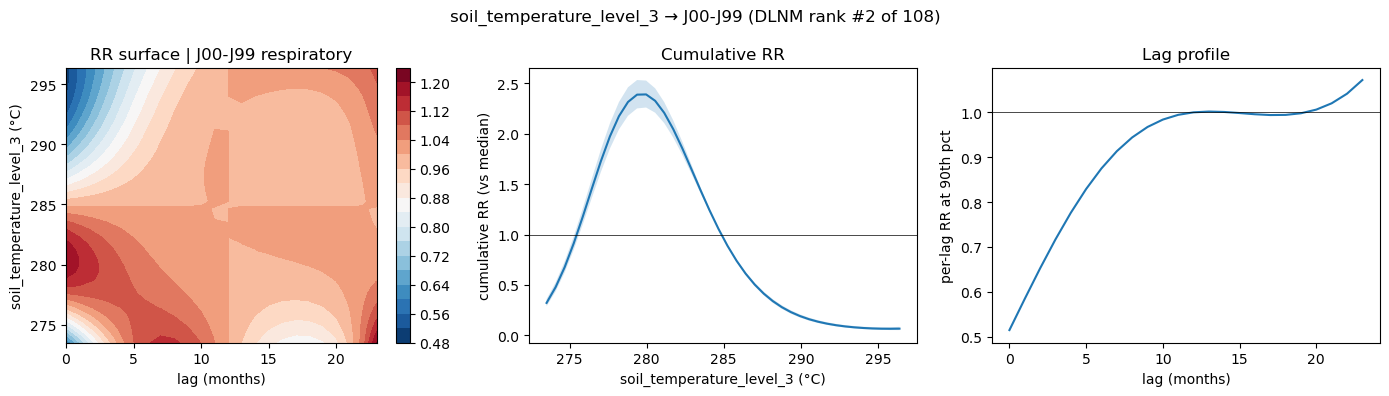

In [12]:
from rq1_dlnm.predict import exposure_lag_surface, lag_profile

v_grid = np.linspace(L.min(), L.max(), 40)
S = exposure_lag_surface(beta=beta, v_grid=v_grid, v_ref=v_med,
                         var_knots=v_knots, lag_knots=lag_knots, nlag=MAX_LAG + 1)
cum_log_rr = np.empty_like(v_grid); cum_se = np.empty_like(v_grid)
for i, v in enumerate(v_grid):
    c = cumulative_rr_contrast(
        beta=beta, cov=cov, v_low=v_med, v_high=float(v),
        var_knots=v_knots, lag_knots=lag_knots, nlag=MAX_LAG + 1,
    )
    cum_log_rr[i] = c.log_rr; cum_se[i] = c.se
lp = lag_profile(beta=beta, v=v_high, v_ref=v_med,
                 var_knots=v_knots, lag_knots=lag_knots, nlag=MAX_LAG + 1)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
c0 = axes[0].contourf(np.arange(MAX_LAG + 1), v_grid, S, levels=20, cmap="RdBu_r")
axes[0].set_xlabel("lag (months)")
axes[0].set_ylabel("soil_temperature_level_3 (°C)")
axes[0].set_title("RR surface | J00-J99 respiratory")
fig.colorbar(c0, ax=axes[0])

rr = np.exp(cum_log_rr)
hi = np.exp(cum_log_rr + 1.96 * cum_se)
lo = np.exp(cum_log_rr - 1.96 * cum_se)
axes[1].plot(v_grid, rr)
axes[1].fill_between(v_grid, lo, hi, alpha=0.2)
axes[1].axhline(1.0, color="k", lw=0.5)
axes[1].set_xlabel("soil_temperature_level_3 (°C)")
axes[1].set_ylabel("cumulative RR (vs median)")
axes[1].set_title("Cumulative RR")

axes[2].plot(np.arange(MAX_LAG + 1), lp)
axes[2].axhline(1.0, color="k", lw=0.5)
axes[2].set_xlabel("lag (months)")
axes[2].set_ylabel("per-lag RR at 90th pct")
axes[2].set_title("Lag profile")

fig.suptitle("soil_temperature_level_3 → J00-J99 (DLNM rank #2 of 108)")
fig.tight_layout()
plt.show()

**Reading the figure.** Left panel: the cumulative RR surface across the 24-month lag window — warm soil months in the recent year drive the response. Middle: cumulative RR vs the median is U-shaped, with the right (warm) tail above 1 and the left (cold) tail dominated by an inflated point estimate that the §10 caveats in the technical report flag as not credibly calibrated. Right: lag profile at the 90th-percentile exposure peaks within the most recent 12 months. The DLNM cumulative log-RR is large and the same pair is the lift-3.7 hit on the FP-Growth side — that **agreement** is the result, not the magnitudes themselves.

## 5. Summary

| step | technique | output |
|---|---|---|
| Stage 1 (offline) | Poisson DLNM with polynomial cross-basis · CBSA FE · ridge β · observed-information SE · BH-FDR | `results/summary.csv` — 108 (exposure × chapter) pairs ranked by |log-RR| |
| Stage 2 (this notebook) | Quartile discretization · FP-Growth · structural env→disease filter | 1,979 association rules sorted by lift |
| Bridge (this notebook) | Join rules to DLNM rank on (exposure, chapter) | Cross-method agreement table |
| Lead figure (this notebook) | Single-pair DLNM re-fit + three-panel plot | `soil_temperature_level_3 → J00-J99` |

**Headline finding.** Hot-soil years (`soil_temperature_level_3_Q4`) co-occur with high-respiratory metro-years (`J00-J99_high`) at lift ≈ 3.7 in FP-Growth, and the same exposure-chapter pair is ranked #2 of 108 by an independently fit DLNM. The contribution is the **method pivot** — DLNM as a ranker that the data underpowers for inference, FP-Growth as a co-occurrence framing that matches the resolution, and the two converging on the same signal list as internal validation. See `docs/rq1_technical_report.html` for the full caveat list (inflated significance, 14-CBSA panel, marginal-not-joint fits).